# Lady-Bandit-Guard sanity-check walkthrough

The guard must keep the bandit away from the reference orbit. Reward at each step is the (negated) sum of guard distances to the reference origin, so the guard is rewarded for staying near the reference and the bandit is rewarded for displacing the guard. Termination triggers when any guard crosses below `breach_distance_m` of the origin.

This notebook builds the scenario, runs a rollout, renders the trajectory, plots the rollout-time diagnostic, and renders the 2D guard-position reward surface.

For framework deep-dive see `examples/workflow_3d_rtn.ipynb`. For the reward formula and knob reference see `docs/games/lady-bandit-guard.md`.

In [1]:
%load_ext autoreload
%autoreload 2

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt

from orbital_game import OrbitalGameEnv, rollout
from orbital_game.env.types import BySide
from orbital_game.games import make_lady_bandit_guard
from orbital_game.policies.library import ZeroControl
from orbital_game.viz import (
    plot_lady_bandit_guard_diagnostic,
    plot_lady_bandit_guard_position_sweep,
    plot_reward_diagnostic,
    plot_reward_position_sweep,
    plot_rollout_panels,
    plot_rollout_rewards,
)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## 1. Build the scenario

`make_lady_bandit_guard` takes one game-specific knob (`breach_distance_m`) plus the standard scenario knobs.

In [2]:
cfg = make_lady_bandit_guard(
    breach_distance_m=10.0,
    n_guards=1,
    n_bandits=1,
    dt=10.0,
    max_horizon_s=2000.0,
    seed=0,
)
print(f"max_steps:           {cfg.max_steps}")
print(f"breach_distance_m:   {cfg.game.breach_distance_m} m")
print(f"reference orbit:     {cfg.reference_orbit.position_eci[:3]} m")

max_steps:           200
breach_distance_m:   10.0 m
reference orbit:     [7000000.       0.       0.] m


## 2. Construct env and run two rollouts (zero-control, two seeds)

In [3]:
env = OrbitalGameEnv(cfg)
guard_policy = ZeroControl(n_vehicles=cfg.n_guards, action_dim=3)
bandit_policy = ZeroControl(n_vehicles=cfg.n_bandits, action_dim=3)
init_ps = BySide(
    guard=lambda c, s, k: None,
    bandit=lambda c, s, k: None,
)
key1, key2 = jax.random.split(jax.random.PRNGKey(42), 2)
traj1 = rollout(env, BySide(guard=guard_policy, bandit=bandit_policy), init_ps, key1, n_steps=cfg.max_steps)
traj2 = rollout(env, BySide(guard=guard_policy, bandit=bandit_policy), init_ps, key2, n_steps=cfg.max_steps)
print(f"rollout 1 episode return:  {float(traj1.sides.guard.reward.sum()):.2f}")
print(f"rollout 2 episode return:  {float(traj2.sides.guard.reward.sum()):.2f}")

rollout 1 episode return:  -333819.35
rollout 2 episode return:  -331390.32


## 3. Trajectory + reward over time

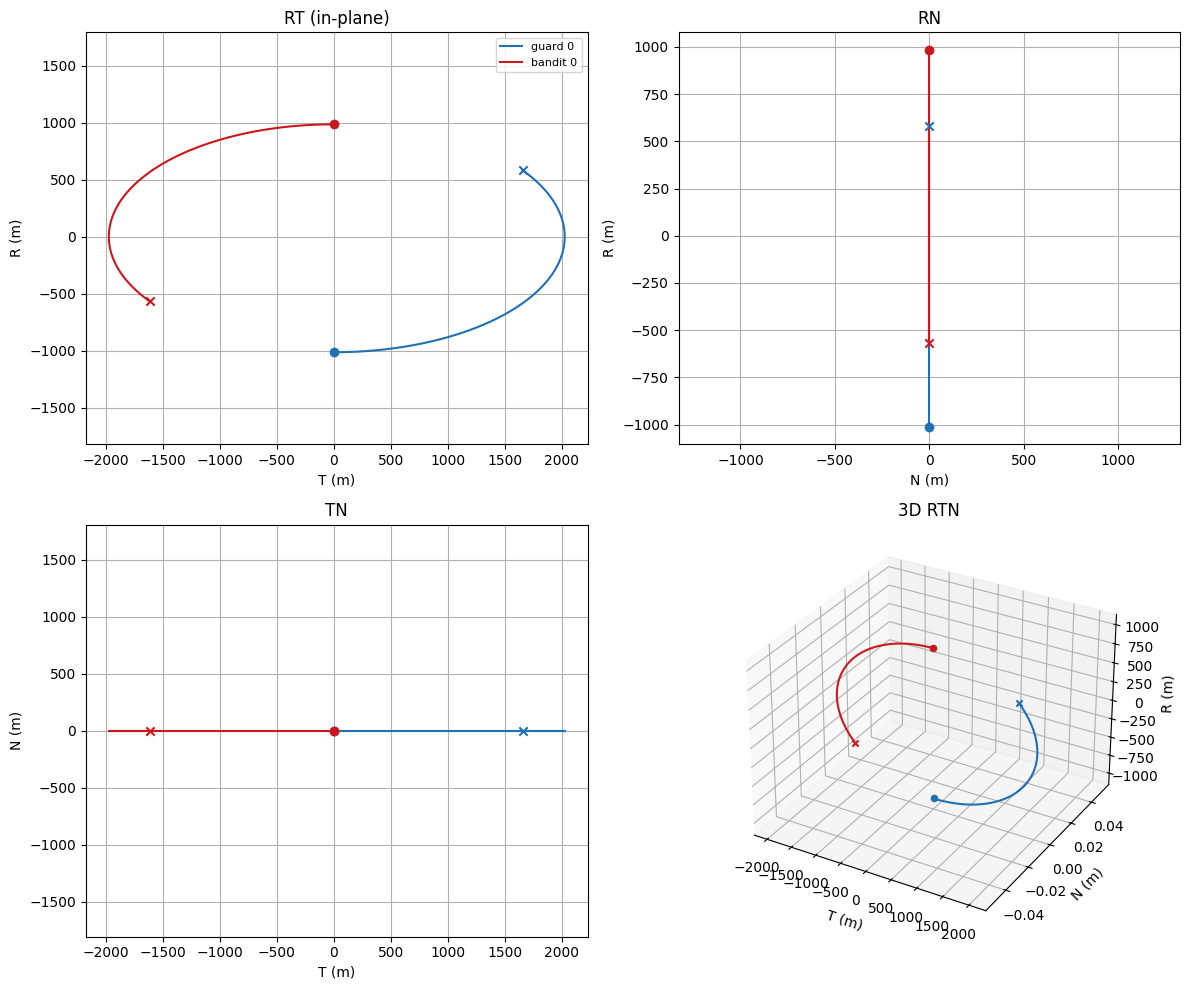

In [4]:
fig = plot_rollout_panels(traj1)
plt.show()

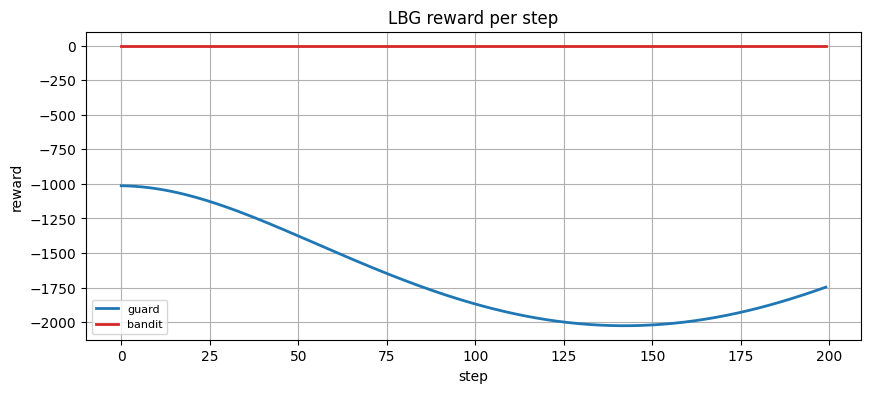

In [5]:
fig, ax = plt.subplots(figsize=(10, 4))
plot_rollout_rewards(traj1, ax=ax)
ax.set_title("LBG reward per step")
plt.show()

## 4. Game-specific rollout diagnostic

The top panel overlays each guard's distance to the reference origin against the breach threshold. The bottom panel overlays the recorded reward against `-Σ|guard|` (the closed-form reward).

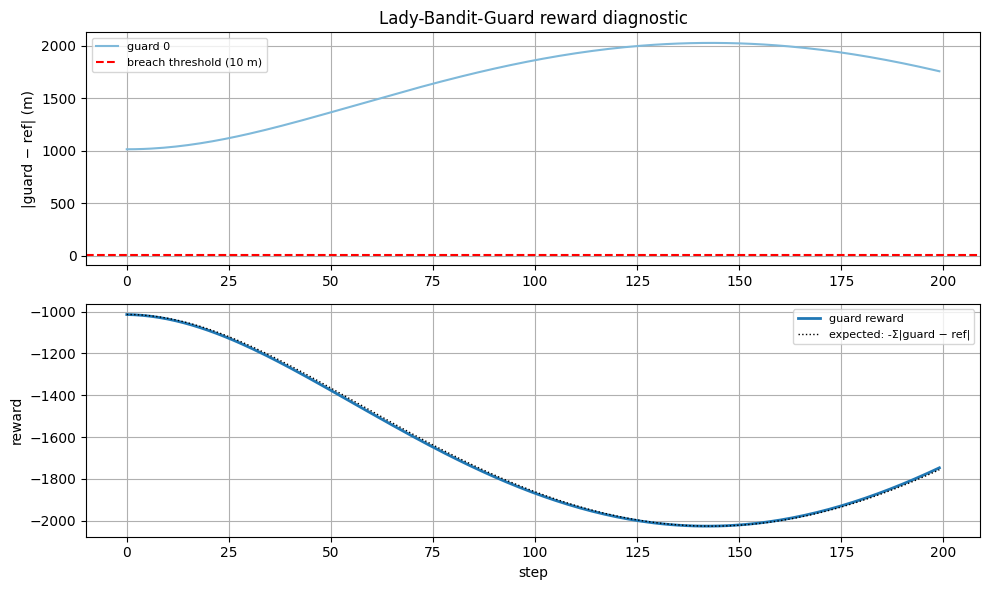

In [6]:
fig = plot_reward_diagnostic(traj1, cfg)
plt.show()

## 5. 2D position-sweep surface

LBG reward only depends on the guard's position (the bandit doesn't enter), so the surface is a downward cone centered at the reference origin. Bandit-side this is a *positive* cone (the bandit's reward is `+Σ|guard|`).

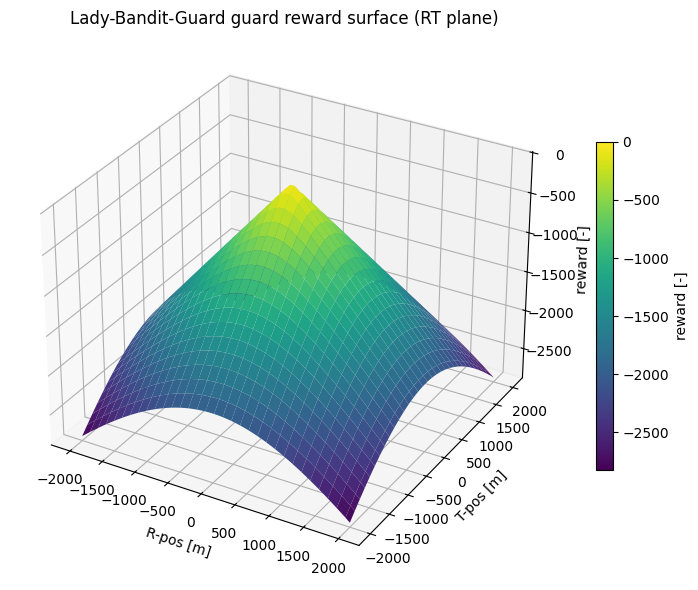

In [7]:
fig = plot_reward_position_sweep(cfg, grid_extent_m=2000.0, grid_steps=64, axis_pair="rt")
plt.show()

## 6. Where to next

- Framework deep-dive: `examples/workflow_3d_rtn.ipynb`
- Game guide: `docs/games/lady-bandit-guard.md`
- Other games: `examples/games/pursuit_evasion.ipynb`, `sun_blocking.ipynb`, `observation_blocking.ipynb`